# Dipole Benchmark Against SPICE QM Dipoles

This notebook compares force-field dipoles from OpenFF, Garnet, and Espaloma against the QM `scf_dipole` values stored in `SPICE-dipoles.hdf5`.

The comparison is done on Garnet's training test split from `training/splits/molecules_test.txt`. The split is used only as a list of SPICE molecule IDs; any ID that is not present in `SPICE-dipoles.hdf5` is skipped. MACE-OFF is not included in this analysis because it does not directly assign atom-centered partial charges.

All comparisons are made on the SPICE/QM conformations. The notebook does not minimize the structures with any force field, so the benchmark isolates the charge model contribution to the dipole rather than mixing charge errors with geometry-relaxation errors.

In [1]:
from pathlib import Path
from contextlib import contextmanager
import csv
import os
import sys
import warnings
warnings.filterwarnings("ignore")

import h5py
import numpy as np
import matplotlib.pyplot as plt

from openmm import NonbondedForce
from openmm.unit import elementary_charge
from openff.toolkit.topology import Molecule, Topology
from openff.units import unit as off_unit

## Paths and Notebook Setup

The notebook can be opened either from the repository root or from `validation/benchmarks`. This setup cell detects the layout, defines the dataset/result paths, and adds `validation/benchmarks` to `sys.path` so the local benchmark helpers can be imported.

`QM_MAG_MIN` is the cutoff used later when plotting QM-relative tensor errors. Since the denominator of that metric is `||D_QM||_F = ||mu_QM||^2`, very small QM dipoles make the relative tensor error ill-conditioned. Rows below this cutoff are kept in the raw data but are marked and omitted from the guarded `D_rel` metric.

In [2]:
CWD = Path.cwd().resolve()

HERE = None
REPO_ROOT = None

for path in (CWD, *CWD.parents):
    if (path / "validation" / "benchmarks" / "src").exists():
        REPO_ROOT = path
        HERE = path / "validation" / "benchmarks"
        break
    if (path / "src").exists() and path.name == "benchmarks":
        HERE = path
        REPO_ROOT = path.parent.parent
        break

if HERE is None:
    raise RuntimeError(
        "Could not find validation/benchmarks/src from the current working directory. "
        f"Current working directory is {CWD}"
    )

sys.path.insert(0, str(HERE))

BOHR_TO_ANGSTROM = 0.529177210903
QM_MAG_MIN = 0.05  # e Angstrom; below this, relative tensor errors are ill-conditioned.
SPICE_FP = HERE / "Datasets" / "spice-dataset-2.0.1" / "SPICE-dipoles.hdf5"
TEST_SPLIT_FP = REPO_ROOT / "training" / "splits" / "molecules_test.txt"
OUT_FP = HERE / "test_split_dipoles.csv"
RESULTS_FP = OUT_FP  # Set this to an existing full-run CSV to replot without rerunning.

SPICE_FP, TEST_SPLIT_FP, RESULTS_FP

@contextmanager
def working_directory(path):
    cwd = Path.cwd()
    os.chdir(path)
    try:
        yield
    finally:
        os.chdir(cwd)

## Check the Dataset and Test Split

This verifies that the downloaded SPICE HDF5 contains QM dipoles and that the Garnet test split IDs are present. The SPICE dipole values are stored as `scf_dipole`, usually in units of `elementary_charge*bohr`.

The SPICE dipole file and Garnet split do not contain exactly the same set of molecule IDs. This check reports how many requested IDs are present and how many of those have `scf_dipole` values. Missing IDs are skipped during the analysis.

In [3]:
def read_molecule_ids(molecule_ids_fp):
    return [
        line.strip()
        for line in Path(molecule_ids_fp).read_text().splitlines()
        if line.strip()
    ]

molecule_ids = read_molecule_ids(TEST_SPLIT_FP)

with h5py.File(SPICE_FP, "r") as f:
    present = [mid for mid in molecule_ids if mid in f]
    missing = [mid for mid in molecule_ids if mid not in f]
    present_with_dipoles = [mid for mid in present if "scf_dipole" in f[mid]]

print(f"test split IDs: {len(molecule_ids)}")
print(f"present in SPICE HDF5: {len(present)}")
print(f"missing from SPICE HDF5: {len(missing)}")
print(f"present with scf_dipole: {len(present_with_dipoles)}")
print("first missing:", missing[:10])

test split IDs: 3000
present in SPICE HDF5: 2957
missing from SPICE HDF5: 43
present with scf_dipole: 2957
first missing: ['maceoff_water_506', 'maceoff_water_439', 'maceoff_water_431', 'maceoff_water_951', 'maceoff_water_235', 'maceoff_water_821', 'maceoff_water_28', 'maceoff_water_1271', 'maceoff_water_968', 'maceoff_water_344']


## Unit Conversions

SPICE downloader files commonly use atomic units. Coordinates are converted to Angstrom and dipoles are converted to `e*Angstrom`, so the force-field dipoles and QM dipoles are expressed in the same unit system.

The tensor quantities later in the notebook therefore have units of `(e Angstrom)^2`, while relative tensor metrics are dimensionless.

In [4]:
def to_angstrom(values, units):
    if units == "angstrom":
        return values
    if units == "nanometers":
        return 10.0 * values
    if units == "bohr":
        return BOHR_TO_ANGSTROM * values
    raise ValueError(f"Unsupported coordinate units: {units!r}")


def dipole_to_e_angstrom(values, units):
    if units == "elementary_charge*angstrom":
        return values
    if units == "elementary_charge*bohr":
        return BOHR_TO_ANGSTROM * values
    raise ValueError(f"Unsupported dipole units: {units!r}")

## Principal-Axis Frame

The absolute orientation of each SPICE conformation in 3D space is arbitrary. To compare dipole components in an orientation-independent way, we define a body frame from the principal axes of inertia of the SPICE/QM geometry.

First, the coordinates are centered at the center of mass for the purpose of building the inertia tensor:

$$
\mathbf{r}'_i = \mathbf{r}_i - \frac{\sum_i m_i \mathbf{r}_i}{\sum_i m_i}
$$

Then the inertia tensor is

$$
\mathbf{I} = \sum_i m_i \left( \|\mathbf{r}'_i\|^2 \mathbf{1} - \mathbf{r}'_i {\mathbf{r}'_i}^T \right).
$$

`np.linalg.eigh` returns the eigenvectors of `I` as columns. These columns form the matrix `A` used as the body-frame axes. Eigenvector signs are arbitrary, so the code flips the third axis whenever needed to enforce a right-handed triad:

$$
\det(\mathbf{A}) > 0.
$$

For disconnected SPICE entries, the same procedure is applied to the full assembly, not to each component separately, because the QM dipole also belongs to the full assembly.

In [5]:
def center_coords(coords, masses):
    return coords - np.sum(masses[:, None] * coords, axis=0) / masses.sum()


def inertia_tensor(centered_coords, masses):
    normsq = np.sum(centered_coords * centered_coords, axis=1)
    return sum(
        m * (r2 * np.eye(3) - np.outer(r, r))
        for m, r2, r in zip(masses, normsq, centered_coords)
    )


def principal_axes(coords, masses):
    moments, axes = np.linalg.eigh(inertia_tensor(center_coords(coords, masses), masses))
    if np.linalg.det(axes) < 0:
        axes[:, 2] *= -1
    return moments, axes

## Dipoles and Projection

For a set of partial charges `q_i`, the force-field dipole in the SPICE coordinate frame is

$$
\boldsymbol{\mu}_{FF}^{lab} = \sum_i q_i \mathbf{r}_i.
$$

SPICE provides the QM dipole directly as `scf_dipole`, also in the dataset coordinate frame after unit conversion. Both vectors are then projected into the same principal-axis body frame:

$$
\boldsymbol{\mu}_{body} = \boldsymbol{\mu}_{lab} \mathbf{A},
$$

where the columns of `A` are the principal axes. The COM-centered coordinates are used to define `A`; the dipole vectors themselves are not re-centered in this notebook. For neutral systems this distinction does not change the dipole, but for non-neutral systems dipoles are origin-dependent, so the output also reports `total_charge` for each backend.

In [6]:
def project_dipole(dipole_lab, axes):
    return dipole_lab @ axes


def charge_dipole(charges, coords):
    return np.sum(charges[:, None] * coords, axis=0)


def dipole_tensor(dipole):
    return np.outer(dipole, dipole)

## Comparison Metrics

The notebook stores the projected QM and force-field dipole components, together with magnitude, vector, angular, and tensor error metrics.

The vector metrics are:

$$
\Delta |\mu| = \|\boldsymbol{\mu}_{FF}\| - \|\boldsymbol{\mu}_{QM}\|,
$$

$$
\Delta \mu_{vec} = \|\boldsymbol{\mu}_{FF} - \boldsymbol{\mu}_{QM}\|,
$$

and the angle between the two projected dipole vectors.

The tensor

$$
\mathbf{D} = \boldsymbol{\mu}\boldsymbol{\mu}^T
$$

has units of `(e Angstrom)^2` and is unchanged by the sign flip `mu -> -mu`, which can happen when an inertia eigenvector flips sign. Its absolute Frobenius difference is

$$
\|\Delta \mathbf{D}\|_F = \|\mathbf{D}_{FF} - \mathbf{D}_{QM}\|_F.
$$

The notebook also stores two dimensionless tensor normalizations. `D_rel_qm` divides by `||D_QM||_F`, which treats QM as the reference but is poorly conditioned when `||mu_QM||` is very small. `D_rel_max` divides by `max(||D_FF||_F, ||D_QM||_F)`, which is more numerically stable but less directly reference-relative. For plotting/reporting, `D_rel` is the guarded QM-relative value and is set to `nan` when `qm_mag < QM_MAG_MIN`.

In [7]:
def compare_dipoles(ff_dipole, qm_dipole):
    ff_mag = np.linalg.norm(ff_dipole)
    qm_mag = np.linalg.norm(qm_dipole)
    ff_tensor = dipole_tensor(ff_dipole)
    qm_tensor = dipole_tensor(qm_dipole)
    D_diff = np.linalg.norm(ff_tensor - qm_tensor, ord="fro")
    ff_tensor_norm = np.linalg.norm(ff_tensor, ord="fro")
    qm_tensor_norm = np.linalg.norm(qm_tensor, ord="fro")
    max_tensor_norm = max(ff_tensor_norm, qm_tensor_norm)

    angle_deg = np.nan
    if ff_mag > 0 and qm_mag > 0:
        cos_angle = np.clip(ff_dipole @ qm_dipole / (ff_mag * qm_mag), -1.0, 1.0)
        angle_deg = np.degrees(np.arccos(cos_angle))

    return {
        "ff_mag": ff_mag,
        "qm_mag": qm_mag,
        "mag_diff": ff_mag - qm_mag,
        "vec_diff": np.linalg.norm(ff_dipole - qm_dipole),
        "angle_deg": angle_deg,
        "D_diff": D_diff,
        "D_rel": np.nan if qm_mag < QM_MAG_MIN else D_diff / qm_tensor_norm,
        "D_rel_qm": np.nan if qm_tensor_norm == 0 else D_diff / qm_tensor_norm,
        "D_rel_max": np.nan if max_tensor_norm == 0 else D_diff / max_tensor_norm,
        "qm_tensor_norm": qm_tensor_norm,
        "small_qm_dipole": qm_mag < QM_MAG_MIN,
    }

## Force-Field Dipoles

Each SPICE entry may contain one covalent molecule or several disconnected components in one mapped SMILES. The QM dipole belongs to the full SPICE assembly, so the benchmark keeps the full coordinate array as the object being compared.

OpenFF, Garnet, and Espaloma all assign atom-centered partial charges through molecule/topology objects. For multicomponent SPICE entries, the code splits the mapped SMILES on `.`, processes each component separately, and then reassembles charges and masses into the original SPICE atom order. The original atom-map numbers are the source of truth for this reassembly. A component is temporarily renumbered to local atom maps `1..n` only so that the OpenFF toolkit can construct that component cleanly.

No force-field minimization is performed. Every backend is compared on the SPICE/QM conformation only.

In [8]:
def component_molecule(component_smiles, coords):
    from rdkit import Chem

    rdmol = Chem.MolFromSmiles(component_smiles, sanitize=False)
    if rdmol is None:
        raise ValueError(f"Could not parse component SMILES: {component_smiles}")

    atom_maps = np.array([atom.GetAtomMapNum() for atom in rdmol.GetAtoms()], dtype=int)
    if np.any(atom_maps <= 0):
        raise ValueError("SPICE SMILES must have one-indexed atom maps for every atom")

    for local_map, atom in enumerate(rdmol.GetAtoms(), start=1):
        atom.SetAtomMapNum(local_map)

    local_smiles = Chem.MolToSmiles(rdmol, isomericSmiles=True, allHsExplicit=True)
    mol = Molecule.from_mapped_smiles(local_smiles, allow_undefined_stereo=True)
    mol.add_conformer(coords[atom_maps - 1] * off_unit.angstrom)
    return mol, atom_maps


def build_components(smiles, coords):
    components = [component_molecule(part, coords) for part in smiles.split(".")]
    atom_maps = np.concatenate([maps for _, maps in components])
    expected = np.arange(1, coords.shape[0] + 1)

    if not np.array_equal(np.sort(atom_maps), expected):
        raise ValueError("SMILES atom maps must uniquely cover the SPICE coordinate atoms")

    masses = np.zeros(coords.shape[0])
    for mol, maps in components:
        masses[maps - 1] = molecule_masses(mol)

    return components, masses


def molecule_masses(mol):
    return np.array([atom.mass.m_as(off_unit.dalton) for atom in mol.atoms])


def charges_from_nonbonded(system):
    for force in system.getForces():
        if isinstance(force, NonbondedForce):
            return np.array([
                force.getParticleParameters(i)[0].value_in_unit(elementary_charge)
                for i in range(system.getNumParticles())
            ])
    raise ValueError("OpenMM system does not contain a NonbondedForce")


_ESPALOMA_MODEL = None
_ESPALOMA_MOD = None
_TORCH_MOD = None


def get_espaloma_model():
    global _ESPALOMA_MODEL, _ESPALOMA_MOD, _TORCH_MOD
    if _ESPALOMA_MODEL is None:
        import espaloma as esp
        import torch

        _ESPALOMA_MOD = esp
        _TORCH_MOD = torch
        _ESPALOMA_MODEL = esp.get_model("latest")
    return _ESPALOMA_MODEL, _ESPALOMA_MOD, _TORCH_MOD


def build_system_espaloma(mol):
    model, esp, torch = get_espaloma_model()
    mgraph = esp.Graph(mol)
    with torch.no_grad():
        model(mgraph.heterograph)
    return esp.graphs.deploy.openmm_system_from_graph(mgraph)


def ff_dipoles(smiles, coords):
    with working_directory(HERE):
        from src.run_model import garnet

    components, masses = build_components(smiles, coords)
    charges = {
        "openff": np.zeros(coords.shape[0]),
        "garnet": np.zeros(coords.shape[0]),
        "espaloma": np.zeros(coords.shape[0]),
    }

    for mol, maps in components:
        top = Topology.from_molecules([mol])

        mol.assign_partial_charges(partial_charge_method="openff-gnn-am1bcc-1.0.0.pt")
        charges["openff"][maps - 1] = mol.partial_charges.m_as("elementary_charge")

        system_garnet, _ = garnet.topology_to_openmm_system(top)
        charges["garnet"][maps - 1] = charges_from_nonbonded(system_garnet)

        system_espaloma = build_system_espaloma(mol)
        charges["espaloma"][maps - 1] = charges_from_nonbonded(system_espaloma)

    return {
        **{
            backend: {"charges": backend_charges}
            for backend, backend_charges in charges.items()
        },
        "masses": masses,
        "n_components": len(components),
    }

## Per-Conformer Comparison

For each conformer, the full SPICE assembly defines the center of mass, inertia tensor, and right-handed principal-axis frame. The SPICE QM dipole and each force-field dipole are projected into that same frame and compared there.

Each output row corresponds to one `(molecule, conformer, backend)` combination. The row includes the projected QM dipole, projected force-field dipole, dipole tensor components, inertia moments, total charge, number of disconnected components, and all scalar comparison metrics.

In [9]:
def compare_conformer(mol_name, conf_i, smiles, coords, qm_dipole_lab):
    data = ff_dipoles(smiles, coords)
    rows = []
    masses = data["masses"]
    moments, axes = principal_axes(coords, masses)
    qm_dipole = project_dipole(qm_dipole_lab, axes)

    for backend in ("openff", "garnet", "espaloma"):
        ff_dipole = project_dipole(charge_dipole(data[backend]["charges"], coords), axes)
        metrics = compare_dipoles(ff_dipole, qm_dipole)

        row = {
            "molecule": mol_name,
            "conformer": conf_i,
            "backend": backend,
            "geometry": "qm",
            "n_components": data["n_components"],
            "total_charge": float(np.sum(data[backend]["charges"])),
            "dipole_qm_x": qm_dipole[0],
            "dipole_qm_y": qm_dipole[1],
            "dipole_qm_z": qm_dipole[2],
            "dipole_ff_x": ff_dipole[0],
            "dipole_ff_y": ff_dipole[1],
            "dipole_ff_z": ff_dipole[2],
            "D_qm_00": qm_dipole[0] * qm_dipole[0],
            "D_qm_01": qm_dipole[0] * qm_dipole[1],
            "D_qm_02": qm_dipole[0] * qm_dipole[2],
            "D_qm_11": qm_dipole[1] * qm_dipole[1],
            "D_qm_12": qm_dipole[1] * qm_dipole[2],
            "D_qm_22": qm_dipole[2] * qm_dipole[2],
            "D_ff_00": ff_dipole[0] * ff_dipole[0],
            "D_ff_01": ff_dipole[0] * ff_dipole[1],
            "D_ff_02": ff_dipole[0] * ff_dipole[2],
            "D_ff_11": ff_dipole[1] * ff_dipole[1],
            "D_ff_12": ff_dipole[1] * ff_dipole[2],
            "D_ff_22": ff_dipole[2] * ff_dipole[2],
            "I0": moments[0],
            "I1": moments[1],
            "I2": moments[2],
        }
        row.update(metrics)
        rows.append(row)

    return rows

## Load SPICE Rows

This iterator follows the Garnet test split order, skips IDs not present in the SPICE dipole file, and yields one conformer at a time. It reads the mapped SMILES, coordinates, and `scf_dipole`, converts coordinates and dipoles to the units used by the analysis, and respects `MAX_MOLS` and `MAX_CONFS` for quick interactive tests.

The conformer coordinates and QM dipoles are yielded together so that each force field is always compared against the QM dipole from the same SPICE conformation.

In [10]:
def iter_spice_rows(spice_fp, molecule_ids, max_mols=None, max_confs=None):
    with h5py.File(spice_fp, "r") as f:
        yielded = 0
        missing = []

        for mol_name in molecule_ids:
            if max_mols is not None and yielded >= max_mols:
                break
            if mol_name not in f:
                missing.append(mol_name)
                continue

            group = f[mol_name]
            if "scf_dipole" not in group:
                raise KeyError(f"{mol_name} has no scf_dipole dataset")

            smiles = group["smiles"][0].decode() if isinstance(group["smiles"][0], bytes) else group["smiles"][0]
            coords_units = group["conformations"].attrs.get("units", "bohr")
            dipole_units = group["scf_dipole"].attrs.get("units", "elementary_charge*bohr")
            coords_all = to_angstrom(group["conformations"][()], coords_units)
            dipoles_all = dipole_to_e_angstrom(group["scf_dipole"][()], dipole_units)

            n_confs = coords_all.shape[0] if max_confs is None else min(max_confs, coords_all.shape[0])
            for conf_i in range(n_confs):
                yield mol_name, conf_i, smiles, coords_all[conf_i], dipoles_all[conf_i]
            yielded += 1

        if missing:
            print(f"Skipped {len(missing)} absent IDs: {missing[:10]}{'...' if len(missing) > 10 else ''}")

## Load or Run the Analysis

The force-field charge assignment is the expensive part. By default this cell loads `RESULTS_FP` and recomputes derived tensor metrics from the saved dipole components. Set `RESULTS_FP` to the CSV from a full run, and leave `RUN_FORCE_FIELD_ANALYSIS = False` to avoid recomputing charges.

Set `RUN_FORCE_FIELD_ANALYSIS = True` only when you need to regenerate the CSV from the SPICE HDF5 file. In that mode, the notebook loops over the test split, assigns charges with each backend, computes one row per `(molecule, conformer, backend)`, and stores the results in `rows`. The later cells operate only on `rows`, so they can be rerun freely for plotting and metric changes.

In [11]:
BACKEND_ORDER = ("openff", "espaloma", "garnet")
BACKENDS = BACKEND_ORDER
QM_MAG_BINS = np.array([0.0, QM_MAG_MIN, 0.1, 0.25, 0.5, 1.0, 2.0, np.inf])
QM_MAG_BIN_LABELS = [
    f"< {QM_MAG_MIN:g}",
    f"{QM_MAG_MIN:g}-0.1",
    "0.1-0.25",
    "0.25-0.5",
    "0.5-1",
    "1-2",
    ">= 2",
]

FLOAT_COLUMNS = {
    "total_charge", "dipole_qm_x", "dipole_qm_y", "dipole_qm_z",
    "dipole_ff_x", "dipole_ff_y", "dipole_ff_z",
    "D_qm_00", "D_qm_01", "D_qm_02", "D_qm_11", "D_qm_12", "D_qm_22",
    "D_ff_00", "D_ff_01", "D_ff_02", "D_ff_11", "D_ff_12", "D_ff_22",
    "I0", "I1", "I2", "ff_mag", "qm_mag", "mag_diff", "vec_diff",
    "angle_deg", "D_diff", "D_rel", "D_rel_qm", "D_rel_max", "qm_tensor_norm",
}
INT_COLUMNS = {"conformer", "n_components"}


def coerce_row(row):
    out = dict(row)
    for key in FLOAT_COLUMNS & out.keys():
        out[key] = float(out[key]) if out[key] not in ("", "nan", "NaN") else np.nan
    for key in INT_COLUMNS & out.keys():
        out[key] = int(float(out[key])) if out[key] not in ("", "nan", "NaN") else 0
    if "small_qm_dipole" in out and isinstance(out["small_qm_dipole"], str):
        out["small_qm_dipole"] = out["small_qm_dipole"].lower() == "true"
    return out


def load_rows(csv_fp):
    with open(csv_fp, newline="") as f:
        return [coerce_row(row) for row in csv.DictReader(f)]


def qm_mag_bin(qm_mag):
    idx = np.searchsorted(QM_MAG_BINS, qm_mag, side="right") - 1
    idx = min(max(idx, 0), len(QM_MAG_BIN_LABELS) - 1)
    return QM_MAG_BIN_LABELS[idx]


def add_tensor_metrics(rows, qm_mag_min=QM_MAG_MIN):
    for row in rows:
        qm = np.array([row["dipole_qm_x"], row["dipole_qm_y"], row["dipole_qm_z"]], dtype=float)
        ff = np.array([row["dipole_ff_x"], row["dipole_ff_y"], row["dipole_ff_z"]], dtype=float)
        ff_tensor = np.outer(ff, ff)
        qm_tensor = np.outer(qm, qm)
        D_diff = np.linalg.norm(ff_tensor - qm_tensor, ord="fro")
        ff_tensor_norm = np.linalg.norm(ff_tensor, ord="fro")
        qm_tensor_norm = np.linalg.norm(qm_tensor, ord="fro")
        max_tensor_norm = max(ff_tensor_norm, qm_tensor_norm)
        qm_mag = np.linalg.norm(qm)

        row["D_diff"] = D_diff
        row["qm_mag"] = qm_mag
        row["ff_mag"] = np.linalg.norm(ff)
        row["qm_tensor_norm"] = qm_tensor_norm
        row["D_rel_qm"] = np.nan if qm_tensor_norm == 0 else D_diff / qm_tensor_norm
        row["D_rel_max"] = np.nan if max_tensor_norm == 0 else D_diff / max_tensor_norm
        row["D_rel"] = np.nan if qm_mag < qm_mag_min else row["D_rel_qm"]
        row["small_qm_dipole"] = qm_mag < qm_mag_min
        row["qm_mag_bin"] = qm_mag_bin(qm_mag)
    return rows


RUN_FORCE_FIELD_ANALYSIS = False
MAX_MOLS = None
MAX_CONFS = None

if not RUN_FORCE_FIELD_ANALYSIS:
    if not RESULTS_FP.exists():
        raise FileNotFoundError(f"Cached results not found: {RESULTS_FP}. Set RESULTS_FP to your full-run CSV or set RUN_FORCE_FIELD_ANALYSIS = True to regenerate it.")
    rows = load_rows(RESULTS_FP)
    print(f"loaded {len(rows)} rows from {RESULTS_FP}")
else:
    rows = []
    for mol_name, conf_i, smiles, coords, qm_dipole in iter_spice_rows(
        SPICE_FP, molecule_ids, max_mols=MAX_MOLS, max_confs=MAX_CONFS
    ):
        try:
            rows.extend(compare_conformer(mol_name, conf_i, smiles, coords, qm_dipole))
            print("processed", mol_name, conf_i)
        except Exception as exc:
            print(f"skipped {mol_name} conformer {conf_i}: {exc}")

rows = add_tensor_metrics(rows)
BACKENDS = tuple(backend for backend in BACKEND_ORDER if any(row["backend"] == backend for row in rows))
small_qm = sum(row["small_qm_dipole"] for row in rows)
print(f"rows: {len(rows)}")
print(f"backends: {BACKENDS}")
print(f"small-QM tensor rows guarded out: {small_qm} ({small_qm / len(rows):.1%})")
len(rows)

with open(OUT_FP, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(rows[0]))
    writer.writeheader()
    writer.writerows(rows)

print(f"wrote {len(rows)} rows to {OUT_FP}")

loaded 123345 rows from /lmb/home/alexandrebg/Documents/Dipole/garnet/validation/benchmarks/test_split_dipoles.csv
rows: 123345
backends: ('openff', 'espaloma', 'garnet')
small-QM tensor rows guarded out: 726 (0.6%)
wrote 123345 rows to /lmb/home/alexandrebg/Documents/Dipole/garnet/validation/benchmarks/test_split_dipoles.csv


In [12]:
METRICS = (
    "mag_diff", "vec_diff", "angle_deg", "D_diff", "D_rel", "D_rel_qm", "D_rel_max", "qm_mag"
)
diffs = {metric: {backend: [] for backend in BACKENDS} for metric in METRICS}

for row in rows:
    backend = row["backend"]
    if backend not in BACKENDS:
        continue
    for metric in METRICS:
        diffs[metric][backend].append(row[metric])

for metric in METRICS:
    for backend in BACKENDS:
        diffs[metric][backend] = np.asarray(diffs[metric][backend], dtype=float)

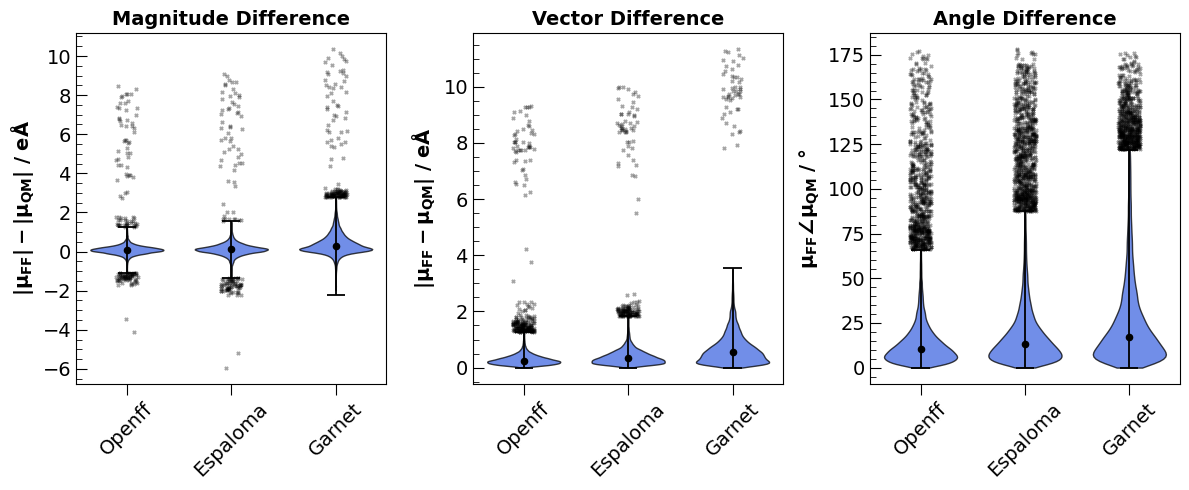

In [13]:
from src.graphs import violin_prune_outliers, style_violins


def style_ax(ax):
    ax.set_xticks(
        np.arange(1, len(BACKENDS) + 1),
        [backend.capitalize() for backend in BACKENDS],
        rotation=45,
    )
    ax.minorticks_on()
    ax.tick_params(labelsize=14, axis="y", which="major", length=8.0, direction="in")
    ax.tick_params(labelsize=14, axis="y", which="minor", length=4.0, direction="in")
    ax.tick_params(labelsize=14, axis="x", which="major", length=8.0, direction="out")
    ax.tick_params(labelsize=14, axis="x", which="minor", length=0.0, direction="in")


fig, ax = plt.subplots(1, 3,
                       figsize = (12, 5),
                       layout = "tight")

parts_mag = violin_prune_outliers(ax[0],
                                  [diffs["mag_diff"][backend] for backend in BACKENDS],
                                  mad_k=10, allow_negative=True)
style_violins(parts_mag)

parts_vec = violin_prune_outliers(ax[1],
                                  [diffs["vec_diff"][backend] for backend in BACKENDS],
                                  mad_k=10, allow_negative=False)
style_violins(parts_vec)

parts_angle = violin_prune_outliers(ax[2],
                                    [diffs["angle_deg"][backend] for backend in BACKENDS],
                                    mad_k=10, allow_negative=False)
style_violins(parts_angle)

ax[0].set_title("Magnitude Difference",
                fontsize = 14, fontweight = "bold")
ax[1].set_title("Vector Difference",
                fontsize = 14, fontweight = "bold")
ax[2].set_title("Angle Difference",
                fontsize = 14, fontweight = "bold")

ax[0].set_ylabel(r"$\mathbf{|\mu_{FF}| - |\mu_{QM}| \ / \ e \AA}$",
                fontsize = 14, fontweight = "bold")
ax[1].set_ylabel(r"$\mathbf{|\mu_{FF} - \mu_{QM}| \ / \ e \AA}$",
                fontsize = 14, fontweight = "bold")
ax[2].set_ylabel(r"$\mathbf{\mu_{FF} \angle \mu_{QM} \ / \ \degree}$",
                fontsize = 14, fontweight = "bold")

style_ax(ax[0])
style_ax(ax[1])
style_ax(ax[2])

fig.savefig("dipole_vector_diffs.pdf", transparent=True)

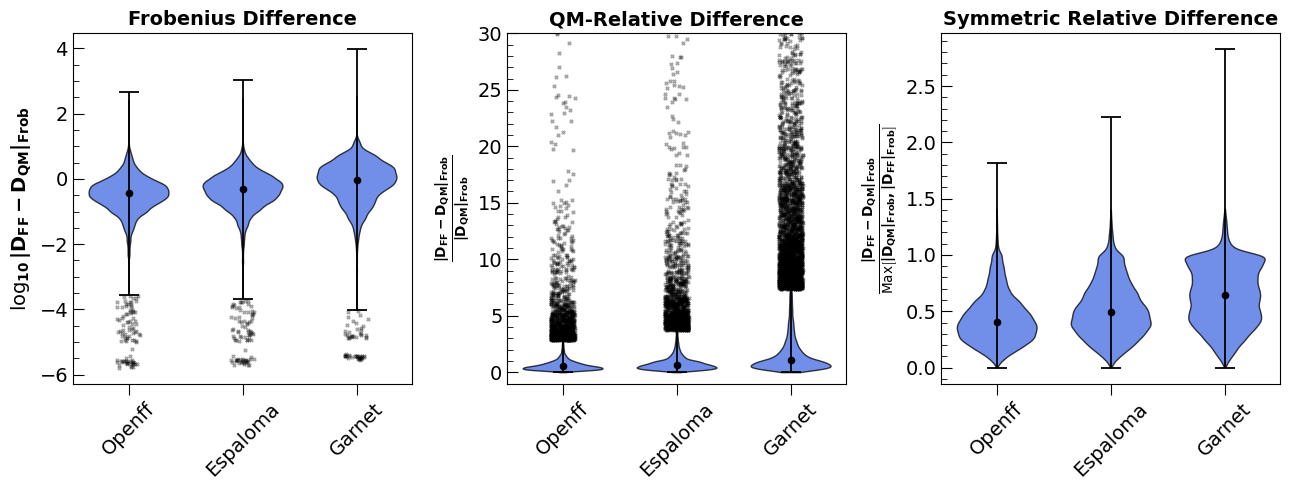

In [14]:
fig, ax = plt.subplots(1, 3,
                       figsize = (13, 5),
                       layout = "tight")

log_D_diff = [np.log10(np.clip(diffs["D_diff"][backend], 1e-12, None)) for backend in BACKENDS]
parts_diff = violin_prune_outliers(ax[0], log_D_diff, mad_k=10, allow_negative=True)
style_violins(parts_diff)

parts_rel = violin_prune_outliers(ax[1],
                                  [diffs["D_rel"][backend] for backend in BACKENDS],
                                  mad_k=10, allow_negative=False)
style_violins(parts_rel)

parts_rel_max = violin_prune_outliers(ax[2],
                                      [diffs["D_rel_max"][backend] for backend in BACKENDS],
                                      mad_k=10, allow_negative=False)
style_violins(parts_rel_max)

ax[0].set_title("Frobenius Difference",
                fontsize = 14, fontweight = "bold")
ax[1].set_title("QM-Relative Difference",
                fontsize = 14, fontweight = "bold")
ax[2].set_title("Symmetric Relative Difference",
                fontsize = 14, fontweight = "bold")

ax[0].set_ylabel(r"$\mathbf{\log_{10} |D_{FF} - D_{QM}|_{Frob}}$",
                fontsize = 14, fontweight = "bold")
ax[1].set_ylabel(r"$\mathbf{\frac{|D_{FF} - D_{QM}|_{Frob}}{|D_{QM}|_{Frob}}}$",
                fontsize = 14, fontweight = "bold")
ax[2].set_ylabel(r"$\mathbf{\frac{|D_{FF} - D_{QM}|_{Frob}}{ \mathrm{Max} \left[ |D_{QM}|_{Frob}, |D_{FF}|_{Frob} \right] }}$",
                fontsize = 14, fontweight = "bold")

ax[1].set_ylim(-1, 30)

style_ax(ax[0])
style_ax(ax[1])
style_ax(ax[2])

fig.savefig("dipole_tensor_diffs.pdf", transparent=True)